In [15]:
import sys
print(sys.version)

3.13.12 (main, Feb  3 2026, 22:52:12) [Clang 21.1.4 ]


# Fast Agent - Build a SQL Agent fast!

<img src="./assets/LC_L1_Top.png" align="left" width="500">

## Setup

Load and/or check for needed environmental variables

In [16]:
from dotenv import load_dotenv
from env_utils import doublecheck_env, doublecheck_pkgs

# Load environment variables from .env
load_dotenv()

# Check and print results
doublecheck_env("example.env")  # check environmental variables
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)   # check packages

GOOGLE_API_KEY=****1zgM
LANGSMITH_API_KEY=****0a4f
LANGSMITH_TRACING=false
LANGSMITH_PROJECT=****ject
Python 3.13.12 satisfies requires-python: >=3.11,<3.14
package                | required | installed | status | path                                                                            
---------------------- | -------- | --------- | ------ | --------------------------------------------------------------------------------
langgraph              | >=1.0.0  | 1.2.9     | ✅ OK   | …repo/github/lca-langchainV1-essentials/python/venv/lib/python3.13/site-packages
langchain              | >=1.3.10 | 1.3.14    | ✅ OK   | …repo/github/lca-langchainV1-essentials/python/venv/lib/python3.13/site-packages
langchain-core         | >=1.4.0  | 1.6.3     | ✅ OK   | …repo/github/lca-langchainV1-essentials/python/venv/lib/python3.13/site-packages
langchain-google-genai | >=2.0.0  | 4.4.0     | ✅ OK   | …repo/github/lca-langchainV1-essentials/python/venv/lib/python3.13/site-packages
langchain-anthr

In [17]:
from sql_db import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

Define the runtime context to provide the agent and tools with access to the database.

In [18]:
from dataclasses import dataclass

from sql_db import SQLDatabase


# define context structure to support dependency injection
@dataclass
class RuntimeContext:
    db: SQLDatabase

<b>⚠️ Security Note:</b> This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️   
This tool will connect to the database. Note the use of `get_runtime` to access the graph **runtime context**.

In [19]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [20]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go!  You can choose many agents from our [integrations](https://docs.langchain.com/oss/python/integrations/providers) list. 

In [21]:
from langchain.agents import create_agent

agent = create_agent(
    model="google_genai:gemini-3.5-flash-lite",
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Here's a display of the agent ReAct Loop.

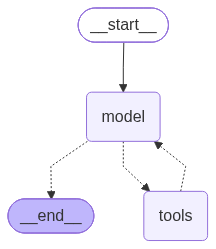

In [8]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Run some queries. Notice:
- The agent does not have the database schema and will need to discover it independently.
- The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
- Notice you invoke the agent with `agent.stream`.
    - This command and the `pretty_print` display the **messages** that communicate information between the model and the tools.
- Notice the agent doesn't remember the schema between invocations... More on this later!

In [9]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================

[]
Tool Calls:
  execute_sql (call_141772)
 Call ID: call_141772
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

[]
Tool Calls:
  execute_sql (call_105072)
 Call ID: call_105072
  Args:
    query: SELECT 'Album' AS table_name, COUNT(*) AS entry_count FROM Album
UNION ALL
SELECT 'Artist', COUNT(*) FROM Artist
UNION ALL
SELECT 'Customer', COUNT(*) FROM Customer
UNION ALL
SELECT 'Employee', COUNT(*) FROM Employee
UNION AL

In [10]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================

[]
Tool Calls:
  execute_sql (call_168058)
 Call ID: call_168058
  Args:
    query: SELECT name, sql FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album', 'CREATE TABLE [Album]\n(\n    [AlbumId] INTEGER  NOT NULL,\n    [Title] NVARCHAR(160)  NOT NULL,\n    [ArtistId] INTEGER  NOT NULL,\n    CONSTRAINT [PK_Album] PRIMARY KEY  ([AlbumId]),\n    FOREIGN KEY ([ArtistId]) REFERENCES [Artist] ([ArtistId]) \n\t\tON DELETE NO ACTION ON UPDATE NO ACTION\n)'), ('Artist', 'CREATE TABLE [Artist]\n(\n    [ArtistId] INTEGER  NOT NULL,\n    [Name] NVARCHAR(120),\n    CONSTRAINT [PK_Artist] PRIMARY KEY  ([ArtistId])\n)'), ('Customer', 'CREATE TABLE [Customer]\n(\n    [CustomerId] INTEGER  NOT NULL,\n

In [11]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================

[]
Tool Calls:
  execute_sql (call_144348)
 Call ID: call_144348
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Here are the tables in the database:\n\n1. **Album**\n2. **Artist**\n3. **Customer**\n4. **Employee**\n5. **Genre**\n6. **Invoice**\n7. **InvoiceLine**\n8. **MediaType**\n9. **Playlist**\n10. **PlaylistTrack**\n11. **Track**', 'extras': {'signature': 'EqoCCqcCARFNMg/Ly1WcVDe4IhKVwqqh1Q+QAybANx4VcEw

**Create your own query here!**  Add some questions of your own.

In [22]:
question = "Дай мне список всех таблиц без форматирования, через запятую в таком формате: имя таблицы (описание таблицы), ..."

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Дай мне список всех таблиц без форматирования, через запятую в таком формате: имя таблицы (описание таблицы), ...
================================== Ai Message ==================================

[]
Tool Calls:
  execute_sql (call_114784)
 Call ID: call_114784
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Album (таблица содержит информацию об альбомах музыки), Artist (таблица содержит информацию об исполнителях), Customer (таблица содержит информацию о клиентах магазина), Employee (таблица содержит информацию о сотру

### Let's try this in Studio